### Task 2.1

In [164]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
import os
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import sys
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Running in local environment (VS Code)")
print(f"Output directory: {OUTPUT_DIR}")



Running in local environment (VS Code)
Output directory: ./outputs


In [165]:
import pandas as pd
import os

# Check if file exists
filepath = '/Users/sanjana/Desktop/sc4020-project-2/data/disease_symptom/dataset.csv'
print(f"File exists: {os.path.exists(filepath)}")

df=pd.read_csv(filepath)

print("Shape of data",df.shape)

File exists: True
Shape of data (4920, 18)


In [166]:
def get_comprehensive_synonym_map():
    return {
        # ------------------ FEVER / CHILLS / TEMP ------------------
        'high fever': 'fever',
        'mild fever': 'fever',
        'shivering': 'chills',
        'cold hands and feets': 'cold extremities',
        'toxic look (typhos)': 'fever',
        'pyrexia': 'fever',
        
        # ------------------ PAIN / ACHES ------------------
        'stomach pain': 'abdominal pain',
        'belly pain': 'abdominal pain',
        'chest pain': 'pain',
        'back pain': 'pain',
        'muscle pain': 'pain',
        'pain behind the eyes': 'headache',
        'hip joint pain': 'joint pain',
        'knee pain': 'joint pain',
        'painful walking': 'pain',
        'neck pain': 'stiff neck',
        
        # ------------------ WEAKNESS / FATIGUE / BALANCE ------------------
        'weakness in limbs': 'muscle weakness',
        'muscle wasting': 'muscle weakness',
        'lethargy': 'fatigue',
        'malaise': 'fatigue',
        'unsteadiness': 'dizziness',
        'loss of balance': 'dizziness',
        'spinning movements': 'dizziness',
        'altered sensorium': 'dizziness',
        'weakness of one body side': 'muscle weakness',
        
        # ------------------ SKIN / RASHES ------------------
        'pus filled pimples': 'skin rash',
        'nodal skin eruptions': 'skin rash',
        'skin peeling': 'skin rash',
        'blister': 'skin rash',
        'scurring': 'skin rash',
        'silver like dusting': 'skin rash',
        'small dents in nails': 'skin rash',
        'inflammatory nails': 'skin rash',
        'red spots over body': 'skin rash',
        'dischromic  patches': 'skin rash',
        'dischromic patches': 'skin rash',
        
        # ------------------ SWELLING / FLUIDS ------------------
        'watering from eyes': 'excessive tearing',
        'stomach bleeding': 'internal bleeding',
        'distention of abdomen': 'abdominal distension',
        'swelling of stomach': 'abdominal distension',
        'fluid overload': 'swelling',
        'swollen legs': 'swelling',
        'swollen blood vessels': 'swelling',
        'puffy face and eyes': 'facial swelling',
        'enlarged thyroid': 'thyroid enlargement',
        'swollen extremeties': 'swelling',
        
        # ------------------ RESPIRATORY ------------------
        'runny nose': 'nasal congestion',
        'continuous sneezing': 'sneezing',
        'phlegm': 'mucus',
        'throat irritation': 'sore throat',
        'redness of eyes': 'red eyes',
        'sinus pressure': 'nasal congestion',
        'blood in sputum': 'bloody cough',
        'rusty sputum': 'bloody cough',
        'breathlessness': 'shortness of breath',
        
        # ------------------ DIGESTIVE ------------------
        'passage of gases': 'flatulence',
        'internal itching': 'itching',
        'acute liver failure': 'liver dysfunction',
        'history of alcohol consumption': 'alcohol consumption',
        'receiving blood transfusion': 'blood transfusion',
        'receiving unsterile injections': 'unsterile injections',
        'coma': 'unconsciousness',
        
        # ------------------ URINARY ------------------
        'dark urine': 'abnormal urine',
        'yellow urine': 'abnormal urine',
        'polyuria': 'excessive urination',
        'bladder discomfort': 'urinary discomfort',
        'foul smell of urine': 'abnormal urine',
        'continuous feel of urine': 'urinary frequency',
        'burning micturition': 'painful urination',
        
        # ------------------ NEUROLOGICAL ------------------
        'lack of concentration': 'poor concentration',
        'visual disturbances': 'vision problems',
        'blurred and distorted vision': 'vision problems',
        'depression': 'mood changes',
        'irritability': 'mood changes',
        'mood swings': 'mood changes',
        'restlessness': 'anxiety',
        'anxiety': 'anxiety',
        
        # ------------------ METABOLIC ------------------
        'excessive hunger': 'increased appetite',
        'increased appetite': 'increased appetite',
        'loss of appetite': 'loss of appetite',
        'patches in throat': 'throat lesions',
        'irregular sugar level': 'abnormal blood sugar',
        'obesity': 'weight gain',
        'weight loss': 'weight loss',
        'weight gain': 'weight gain',
        
        # ------------------ CARDIOVASCULAR ------------------
        'fast heart rate': 'tachycardia',
        'palpitations': 'tachycardia',
        'prominent veins on calf': 'varicose veins',
        
        # ------------------ MOVEMENT / SPEECH ------------------
        'slurred speech': 'speech problems',
        'loss of smell': 'anosmia',
        'movement stiffness': 'stiffness',
        'cramps': 'muscle cramps',
        'bruising': 'easy bruising',
        
        # ------------------ REPRODUCTIVE / HORMONAL ------------------
        'abnormal menstruation': 'menstrual irregularity',
        'brittle nails': 'nail problems',
        
        # ------------------ GASTROINTESTINAL ------------------
        'acidity': 'acid reflux',
        'ulcers on tongue': 'mouth ulcers',
        'mucoid sputum': 'mucus',
        'family history': 'family history',
    }

In [167]:
# APRIORI ALGORITHM IMPLEMENTATION
# Agrawal, R., & Srikant, R. (1994). "Fast algorithms for mining association rules"


class AprioriAlgorithm:
    
    def __init__(self, min_support=0.1, min_confidence=0.5):
        """
        Initialize Apriori algorithm with parameters.
        
        Args:
            min_support (float): Minimum support threshold (0-1)
            min_confidence (float): Minimum confidence for association rules (0-1)
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.frequent_itemsets = {}
        self.association_rules = []
        
    def get_unique_items(self, transactions):
        
        unique_items = set()
        for transaction in transactions:
            for item in transaction:
                unique_items.add(frozenset([item]))
        return unique_items
    
    def calculate_support(self, itemset, transactions):
        
        count = 0
        for transaction in transactions:
            if itemset.issubset(transaction):
                count += 1
        support_ratio = count / len(transactions)
        return count, support_ratio
    
    def generate_candidates(self, prev_frequent_itemsets, k):
        
        candidates = set()
        n = len(prev_frequent_itemsets)
        
        # Join step: combine itemsets with k-2 common items
        for i in range(n):
            for j in range(i + 1, n):
                # Union of two k-1 itemsets
                candidate = prev_frequent_itemsets[i] | prev_frequent_itemsets[j]
                
                # Check if size is k (should have exactly k items)
                if len(candidate) == k:
                    candidates.add(candidate)
        
        return candidates
    
    def prune_candidates(self, candidates, prev_frequent_itemsets, k):
        
        pruned_candidates = set()
        
        for candidate in candidates:
            # Get all k-1 subsets
            subsets = [frozenset(s) for s in combinations(candidate, k - 1)]
            
            # Check if all subsets are frequent
            all_frequent = all(subset in prev_frequent_itemsets for subset in subsets)
            
            if all_frequent:
                pruned_candidates.add(candidate)
        
        return pruned_candidates
    
    def fit(self, transactions, verbose=True):
        
        # Convert transactions to list of sets
        transactions = [set(t) for t in transactions]
        n_transactions = len(transactions)
        
        if verbose:
            print(f"Running Apriori Algorithm")
            print(f"Total transactions: {n_transactions}")
            print(f"Minimum support: {self.min_support} ({int(self.min_support * n_transactions)} transactions)")
            print("=" * 60)
        
        # Initialize with 1-itemsets
        k = 1
        candidates = self.get_unique_items(transactions)
        frequent_itemsets_dict = {}
        
        while candidates:
            if verbose:
                print(f"\nIteration k={k}:")
                print(f"  Candidates: {len(candidates)}")
            
            # Calculate support for all candidates
            frequent_k_itemsets = []
            itemset_support = {}
            
            for itemset in candidates:
                count, support = self.calculate_support(itemset, transactions)
                
                if support >= self.min_support:
                    frequent_k_itemsets.append(itemset)
                    itemset_support[itemset] = {'count': count, 'support': support}
            
            if not frequent_k_itemsets:
                break
            
            frequent_itemsets_dict[k] = itemset_support
            
            if verbose:
                print(f"  Frequent itemsets: {len(frequent_k_itemsets)}")
            
            # Generate candidates for next iteration
            k += 1
            if k == 2:
                # For k=2, just combine all 1-itemsets
                candidates = set()
                items = list(frequent_k_itemsets)
                for i in range(len(items)):
                    for j in range(i + 1, len(items)):
                        candidates.add(items[i] | items[j])
            else:
                # For k>2, use the generate and prune method
                candidates = self.generate_candidates(frequent_k_itemsets, k)
                if k > 2:
                    prev_frequent_set = set(frequent_k_itemsets)
                    candidates = self.prune_candidates(candidates, prev_frequent_set, k)
        
        self.frequent_itemsets = frequent_itemsets_dict
        
        if verbose:
            print("\n" + "=" * 60)
            print("Apriori Algorithm Completed!")
            total_frequent = sum(len(itemsets) for itemsets in frequent_itemsets_dict.values())
            print(f"Total frequent itemsets found: {total_frequent}")
        
        return frequent_itemsets_dict
    
    def generate_association_rules(self, min_confidence=None, verbose=True):
        
        if min_confidence is None:
            min_confidence = self.min_confidence
        
        rules = []
        
        # Only generate rules from itemsets of size >= 2
        for k in range(2, max(self.frequent_itemsets.keys()) + 1):
            if k not in self.frequent_itemsets:
                continue
            
            for itemset, metrics in self.frequent_itemsets[k].items():
                items = list(itemset)
                
                # Generate all possible rules from this itemset
                for i in range(1, len(items)):
                    # Generate all antecedents of size i
                    for antecedent_tuple in combinations(items, i):
                        antecedent = frozenset(antecedent_tuple)
                        consequent = itemset - antecedent
                        
                        # Calculate confidence
                        # Confidence(A->B) = Support(A∪B) / Support(A)
                        antecedent_size = len(antecedent)
                        if antecedent_size in self.frequent_itemsets:
                            if antecedent in self.frequent_itemsets[antecedent_size]:
                                antecedent_support = self.frequent_itemsets[antecedent_size][antecedent]['support']
                                confidence = metrics['support'] / antecedent_support
                                
                                if confidence >= min_confidence:
                                    # Calculate lift
                                    consequent_size = len(consequent)
                                    if consequent_size in self.frequent_itemsets:
                                        if consequent in self.frequent_itemsets[consequent_size]:
                                            consequent_support = self.frequent_itemsets[consequent_size][consequent]['support']
                                            lift = confidence / consequent_support
                                        else:
                                            lift = None
                                    else:
                                        lift = None
                                    
                                    rules.append({
                                        'antecedent': antecedent,
                                        'consequent': consequent,
                                        'support': metrics['support'],
                                        'confidence': confidence,
                                        'lift': lift
                                    })
        
        self.association_rules = sorted(rules, key=lambda x: x['confidence'], reverse=True)
        
        if verbose:
            print(f"\nGenerated {len(self.association_rules)} association rules")
            print(f"Minimum confidence threshold: {min_confidence}")
        
        return self.association_rules



In [168]:
def display_sample_style_output(frequent_itemsets, min_support, n_transactions):
    
    print("\n" + "=" * 70)
    print("--- Apriori Analysis Parameters (Stochastically Augmented) ---")
    print(f"Total Transactions (Diseases): {n_transactions} (N=41 Original + N=41 Noisy Mirror)")
    print(f"Minimum Support (MIN_SUPPORT): {min_support} ({min_support*100:.0f}%)")
    min_count = int(np.ceil(n_transactions * min_support))
    print(f"Minimum Absolute Count Required: {min_count} diseases")
    print("-" * 70)
    
    # Extract size-2 itemsets (pairs) only - matching sample's filter
    pairs = []
    if 2 in frequent_itemsets:
        for itemset, metrics in frequent_itemsets[2].items():
            pairs.append({
                'support': metrics['support'],
                'itemsets': tuple(sorted(itemset))
            })
    
    # Sort by support (descending) - highest support first
    pairs = sorted(pairs, key=lambda x: x['support'], reverse=True)
    
    # Display in sample's table format
    print("\n--- Top 10 Frequent Co-occurring Symptom Combinations ---")
    print("These are symptom combinations that frequently appear together in the same disease profile.")
    
    # Print table header (optional, sample doesn't have it but makes it clearer)
    # print(f"{'#':>3} {'support':>8}  {'itemsets'}")
    
    for i, pair in enumerate(pairs[:10]):
        symptoms = ', '.join(pair['itemsets'])
        print(f"{i:>3} {pair['support']:>8.4f}  ({symptoms})")
    
    # Interpretation summary - exactly like the sample
    if pairs:
        top = pairs[0]
        symptoms_list = list(top['itemsets'])
        print("\n--- Interpretation Summary ---")
        print(f"The strongest co-occurrence pattern found is: {symptoms_list}")
        print(f"Support: {top['support']:.4f}")
        pct = top['support'] * 100
        print(f"This pattern appears together in {pct:.2f}% of all diseases in the stochastically augmented dataset (i.e., in {min_count} or more transactions).")
    else:
        print("\n--- Interpretation Summary ---")
        print("No co-occurring symptom pairs found at this support threshold.")
        print(f"Try lowering MIN_SUPPORT below {min_support}.")
    
    print("=" * 70 + "\n")

In [169]:
def load_disease_symptom_data(filepath):
    
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
        print(f"\nColumns: {df.columns.tolist()}")
        return df
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found.")
        print("Please place the dataset CSV in the same directory as this script.")
        print("Or update the filepath in the main() function.")
        return None

In [170]:
def clean_symptoms(symptom):
    if pd.isna(symptom) or symptom == '' or symptom.strip() == '':
        return None
    
    # Convert to lowercase and strip whitespace
    symptom = str(symptom).lower().strip()
    
    # Remove special characters but keep underscores and hyphens
    symptom = symptom.replace('_', ' ')
    
    return symptom


In [171]:
def prepare_transactions(df, normalize_synonyms=True, verbose=True):
    if verbose:
        print("="*60)
        print("DATA PREPARATION")
        print("="*60)
        print(f"Input dataframe shape: {df.shape}")
    
    # Get symptom columns
    symptom_cols = [col for col in df.columns if 'Symptom' in col]
    if verbose:
        print(f"Symptom columns found: {len(symptom_cols)}")
    
    # Transform wide format to long format (like the sample)
    df_long = df.melt(
        id_vars=['Disease'], 
        value_vars=symptom_cols,
        value_name='Symptom'
    )
    
    if verbose:
        print(f"After melting: {df_long.shape}")
    
    # Data Cleaning
    df_long['Symptom'] = df_long['Symptom'].str.lower().str.strip()
    df_long = df_long.dropna(subset=['Symptom'])
    df_long['Symptom'] = df_long['Symptom'].str.replace('_', ' ')
    
    if verbose:
        print(f"After cleaning: {df_long.shape}")
        print(f"Unique symptoms before normalization: {df_long['Symptom'].nunique()}")
    
    # Apply synonym normalization
    if normalize_synonyms:
        synonym_map = get_comprehensive_synonym_map()
        df_long['Symptom'] = df_long['Symptom'].map(lambda x: synonym_map.get(x, x))
        
        if verbose:
            print(f"Unique symptoms after normalization: {df_long['Symptom'].nunique()}")
    
    # CRITICAL FIX: Group by disease to create transactions
    # Each UNIQUE disease becomes ONE transaction
    transactions = []
    disease_names = []
    
    for disease, group in df_long.groupby('Disease'):
        symptoms = set(group['Symptom'].unique())
        if symptoms:
            transactions.append(symptoms)
            disease_names.append(disease)
    
    # Calculate symptom statistics
    symptom_counts = df_long['Symptom'].value_counts()
    symptom_stats = symptom_counts.to_dict()
    
    if verbose:
        print("\n" + "="*60)
        print("TRANSACTION SUMMARY")
        print("="*60)
        print(f"Total Unique Disease Profiles (Transactions): {len(transactions)}")
        print(f"Unique diseases: {len(set(disease_names))}")
        print(f"Unique symptoms: {len(symptom_stats)}")
        
        symptoms_per_transaction = [len(t) for t in transactions]
        print(f"\nSymptoms per transaction:")
        print(f"  Min: {min(symptoms_per_transaction)}")
        print(f"  Max: {max(symptoms_per_transaction)}")
        print(f"  Mean: {np.mean(symptoms_per_transaction):.2f}")
        
        print(f"\nTop 10 most frequent symptoms:")
        for i, (symptom, count) in enumerate(symptom_counts.head(10).items(), 1):
            pct = (count / len(transactions)) * 100
            print(f"  {i:2d}. {symptom:30s}: {count:3d} ({pct:5.1f}%)")
    
    return transactions, disease_names, symptom_stats

In [172]:
def augment_transactions(transactions, disease_names, noise_rate=0.05, verbose=True):
    if verbose:
        print("\n" + "="*60)
        print("DATA AUGMENTATION")
        print("="*60)
        print(f"Original transactions: {len(transactions)}")
        print(f"Noise rate: {noise_rate*100:.1f}%")
    
    augmented_transactions = transactions.copy()
    augmented_names = disease_names.copy()
    
    # Create noisy mirrors
    mirror_count = 0
    symptoms_removed = []
    
    for i, transaction in enumerate(transactions):
        noisy_transaction = transaction.copy()
        original_size = len(noisy_transaction)
        
        # Randomly remove symptoms based on noise_rate
        symptoms_to_remove = [s for s in noisy_transaction 
                             if np.random.rand() < noise_rate]
        
        for symptom in symptoms_to_remove:
            noisy_transaction.discard(symptom)
        
        removed = original_size - len(noisy_transaction)
        symptoms_removed.append(removed)
        
        # Only add if we still have symptoms
        if noisy_transaction:
            augmented_transactions.append(noisy_transaction)
            augmented_names.append(disease_names[i] + '_NOISY_MIRROR')
            mirror_count += 1
    
    if verbose:
        print(f"Noisy mirrors created: {mirror_count}")
        print(f"Augmented transactions: {len(augmented_transactions)}")
        print(f"Increase: +{len(augmented_transactions) - len(transactions)}")
        
        if symptoms_removed:
            print(f"\nSymptoms removed per mirror:")
            print(f"  Mean: {np.mean(symptoms_removed):.2f}")
            print(f"  Max: {max(symptoms_removed)}")
    
    return augmented_transactions, augmented_names

In [173]:
def visualize_symptom_distribution(symptom_stats, top_n=20):
    """
    Visualize symptom distribution.
    Works with both old and new symptom_stats format.
    """
    import matplotlib.pyplot as plt
    
    # Convert symptom_stats to a sorted list of (symptom, count) tuples
    if isinstance(symptom_stats, dict):
        if 'most_common_symptoms' in symptom_stats:
            # Old format
            sorted_symptoms = symptom_stats['most_common_symptoms'][:top_n]
        else:
            # New format (what corrected prepare_transactions returns)
            sorted_symptoms = sorted(symptom_stats.items(), 
                                   key=lambda x: x[1], 
                                   reverse=True)[:top_n]
    else:
        raise ValueError("symptom_stats must be a dictionary")
    
    if not sorted_symptoms:
        print("No symptom data to visualize")
        return
    
    symptoms, counts = zip(*sorted_symptoms)
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # LEFT PLOT: Top symptoms bar chart
    axes[0].barh(range(len(symptoms)), counts, color='steelblue')
    axes[0].set_yticks(range(len(symptoms)))
    axes[0].set_yticklabels(symptoms)
    axes[0].set_xlabel('Frequency')
    axes[0].set_title(f'Top {top_n} Most Common Symptoms')
    axes[0].invert_yaxis()
    
    # Add count labels
    for i, count in enumerate(counts):
        axes[0].text(count + 0.5, i, f'{count}', va='center', fontsize=9)
    
    # RIGHT PLOT: Histogram
    if 'most_common_symptoms' in symptom_stats:
        all_counts = [c for _, c in symptom_stats['most_common_symptoms']]
    else:
        all_counts = list(symptom_stats.values())
    
    axes[1].hist(all_counts, bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Number of Symptoms')
    axes[1].set_title('Distribution of Symptom Frequencies')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    save_path = f'{OUTPUT_DIR}/symptom_distribution.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()

In [174]:
def visualize_frequent_itemsets(frequent_itemsets, top_n=15):
    
    # Collect all itemsets with support
    all_itemsets = []
    for k, itemsets_dict in frequent_itemsets.items():
        for itemset, metrics in itemsets_dict.items():
            all_itemsets.append({
                'itemset': ', '.join(sorted(itemset)),
                'size': k,
                'support': metrics['support'],
                'count': metrics['count']
            })
    
    # Sort by support
    all_itemsets = sorted(all_itemsets, key=lambda x: x['support'], reverse=True)[:top_n]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top itemsets by support
    itemsets_labels = [item['itemset'][:50] + '...' if len(item['itemset']) > 50 
                       else item['itemset'] for item in all_itemsets]
    supports = [item['support'] for item in all_itemsets]
    colors = plt.cm.viridis([item['size'] / max([i['size'] for i in all_itemsets]) 
                             for item in all_itemsets])
    
    axes[0].barh(range(len(itemsets_labels)), supports, color=colors)
    axes[0].set_yticks(range(len(itemsets_labels)))
    axes[0].set_yticklabels(itemsets_labels, fontsize=8)
    axes[0].set_xlabel('Support')
    axes[0].set_title(f'Top {top_n} Frequent Symptom Combinations by Support')
    axes[0].invert_yaxis()
    
    # Itemsets by size
    size_counts = defaultdict(int)
    for itemset_dict in all_itemsets:
        size_counts[itemset_dict['size']] += 1
    
    sizes = sorted(size_counts.keys())
    counts = [size_counts[s] for s in sizes]
    
    axes[1].bar(sizes, counts, color='teal', edgecolor='black')
    axes[1].set_xlabel('Itemset Size (number of symptoms)')
    axes[1].set_ylabel('Number of Frequent Itemsets')
    axes[1].set_title('Distribution of Frequent Itemsets by Size')
    axes[1].set_xticks(sizes)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/frequent_itemsets.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/frequent_itemsets.png")

In [175]:
def visualize_association_rules(rules, top_n=15):
    if not rules:
        print("No association rules to visualize.")
        return
    
    # Get top rules
    top_rules = rules[:top_n]
    
    
    # PLOT 1: Top Rules by Confidence
    plt.figure(figsize=(12, 8))
    
    rule_labels = [f"{', '.join(sorted(r['antecedent']))} → {', '.join(sorted(r['consequent']))}"[:70] 
                   for r in top_rules]
    confidences = [r['confidence'] for r in top_rules]
    
    plt.barh(range(len(rule_labels)), confidences, color='salmon')
    plt.yticks(range(len(rule_labels)), rule_labels, fontsize=9)
    plt.xlabel('Confidence', fontsize=12)
    plt.title(f'Top {top_n} Association Rules by Confidence', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.xlim([0, 1])
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rules_by_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/rules_by_confidence.png")
    
    
    # PLOT 2: Support vs Confidence Scatter
    plt.figure(figsize=(10, 8))
    
    all_supports = [r['support'] for r in rules]
    all_confidences = [r['confidence'] for r in rules]
    
    plt.scatter(all_supports, all_confidences, alpha=0.6, color='purple', s=50, edgecolors='black', linewidth=0.5)
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.title('Association Rules: Support vs Confidence', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/support_vs_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/support_vs_confidence.png")
    
    
    # PLOT 3: Lift Distribution
    plt.figure(figsize=(10, 8))
    
    all_lifts = [r['lift'] for r in rules if r['lift'] is not None]
    
    plt.hist(all_lifts, bins=20, color='green', edgecolor='black', alpha=0.7)
    plt.xlabel('Lift', fontsize=12)
    plt.ylabel('Number of Rules', fontsize=12)
    plt.title('Distribution of Lift Values', fontsize=14, fontweight='bold')
    plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Lift = 1 (independence)')
    plt.legend(fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/lift_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/lift_distribution.png")
    
    
    # PLOT 4: Top Rules by Lift
    plt.figure(figsize=(12, 8))
    
    rules_with_lift = [r for r in rules if r['lift'] is not None]
    top_lift_rules = sorted(rules_with_lift, key=lambda x: x['lift'], reverse=True)[:top_n]
    
    lift_labels = [f"{', '.join(sorted(r['antecedent']))} → {', '.join(sorted(r['consequent']))}"[:70] 
                   for r in top_lift_rules]
    lifts = [r['lift'] for r in top_lift_rules]
    
    plt.barh(range(len(lift_labels)), lifts, color='orange')
    plt.yticks(range(len(lift_labels)), lift_labels, fontsize=9)
    plt.xlabel('Lift', fontsize=12)
    plt.title(f'Top {top_n} Association Rules by Lift', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=2)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rules_by_lift.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/rules_by_lift.png")
    
    print(f"\n All 4 plots saved successfully!")

In [176]:
def print_summary_statistics(frequent_itemsets, rules):
    
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    
    # Frequent itemsets statistics
    print("\n Frequent Itemsets:")
    total_itemsets = sum(len(itemsets) for itemsets in frequent_itemsets.values())
    print(f"  Total frequent itemsets: {total_itemsets}")
    
    for k in sorted(frequent_itemsets.keys()):
        print(f"  Size {k}: {len(frequent_itemsets[k])} itemsets")
    
    # Association rules statistics
    print(f"\n Association Rules:")
    print(f"  Total rules generated: {len(rules)}")
    
    if rules:
        avg_confidence = np.mean([r['confidence'] for r in rules])
        avg_support = np.mean([r['support'] for r in rules])
        lifts = [r['lift'] for r in rules if r['lift'] is not None]
        avg_lift = np.mean(lifts) if lifts else 0
        
        print(f"  Average confidence: {avg_confidence:.4f}")
        print(f"  Average support: {avg_support:.4f}")
        print(f"  Average lift: {avg_lift:.4f}")
        
        # Top 5 rules
        print(f"\n Top 5 Rules by Confidence:")
        for i, rule in enumerate(rules[:5], 1):
            ant = ', '.join(rule['antecedent'])
            cons = ', '.join(rule['consequent'])
            lift_str = f"{rule['lift']:.4f}" if rule['lift'] is not None else "N/A"
            print(f"  {i}. {ant} → {cons} | Supp: {rule['support']:.4f}, Conf: {rule['confidence']:.4f}, Lift: {lift_str}")


In [177]:
def save_results_to_csv(frequent_itemsets, rules):
    
    # Save frequent itemsets
    itemsets_data = []
    for k, itemsets_dict in frequent_itemsets.items():
        for itemset, metrics in itemsets_dict.items():
            itemsets_data.append({
                'itemset': ', '.join(sorted(itemset)),
                'size': k,
                'support': metrics['support'],
                'count': metrics['count']
            })
    
    df_itemsets = pd.DataFrame(itemsets_data)
    df_itemsets = df_itemsets.sort_values('support', ascending=False)
    df_itemsets.to_csv(f'{OUTPUT_DIR}/frequent_itemsets.csv', index=False)
    print(f"\nSaved: {OUTPUT_DIR}/frequent_itemsets.csv")
    
    # Save association rules
    if rules:
        rules_data = []
        for rule in rules:
            rules_data.append({
                'antecedent': ', '.join(rule['antecedent']),
                'consequent': ', '.join(rule['consequent']),
                'support': rule['support'],
                'confidence': rule['confidence'],
                'lift': rule['lift']
            })
        
        df_rules = pd.DataFrame(rules_data)
        df_rules.to_csv(f'{OUTPUT_DIR}/association_rules.csv', index=False)
        print(f"Saved: {OUTPUT_DIR}/association_rules.csv")


TASK 2.1: ANALYSIS OF SYMPTOM CO-OCCURRENCE PATTERNS
Using Apriori Algorithm

 STEP 1: Loading Dataset...
Dataset loaded successfully!
Shape: (4920, 18)

Columns: ['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

Dataset preview:
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic

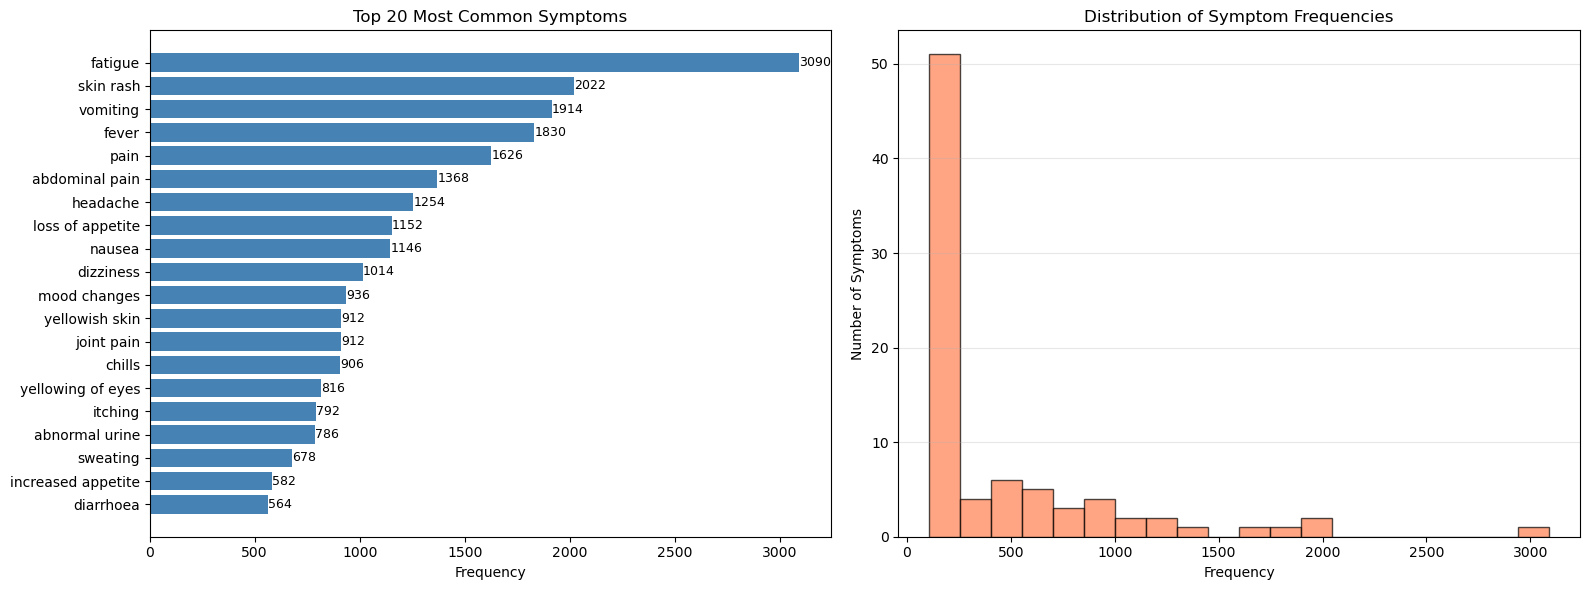


 STEP 5: Running Apriori Algorithm...

Parameters:
  Total transactions: 82
  Minimum support: 0.1 (10%)
  Minimum absolute count: 9 transactions
  Minimum confidence: 0.5 (50%)

Running Apriori Algorithm
Total transactions: 82
Minimum support: 0.1 (8 transactions)

Iteration k=1:
  Candidates: 83
  Frequent itemsets: 20

Iteration k=2:
  Candidates: 190
  Frequent itemsets: 35

Iteration k=3:
  Candidates: 45
  Frequent itemsets: 16

Iteration k=4:
  Candidates: 1
  Frequent itemsets: 1

Apriori Algorithm Completed!
Total frequent itemsets found: 72

 STEP 6: Visualizing Frequent Itemsets...


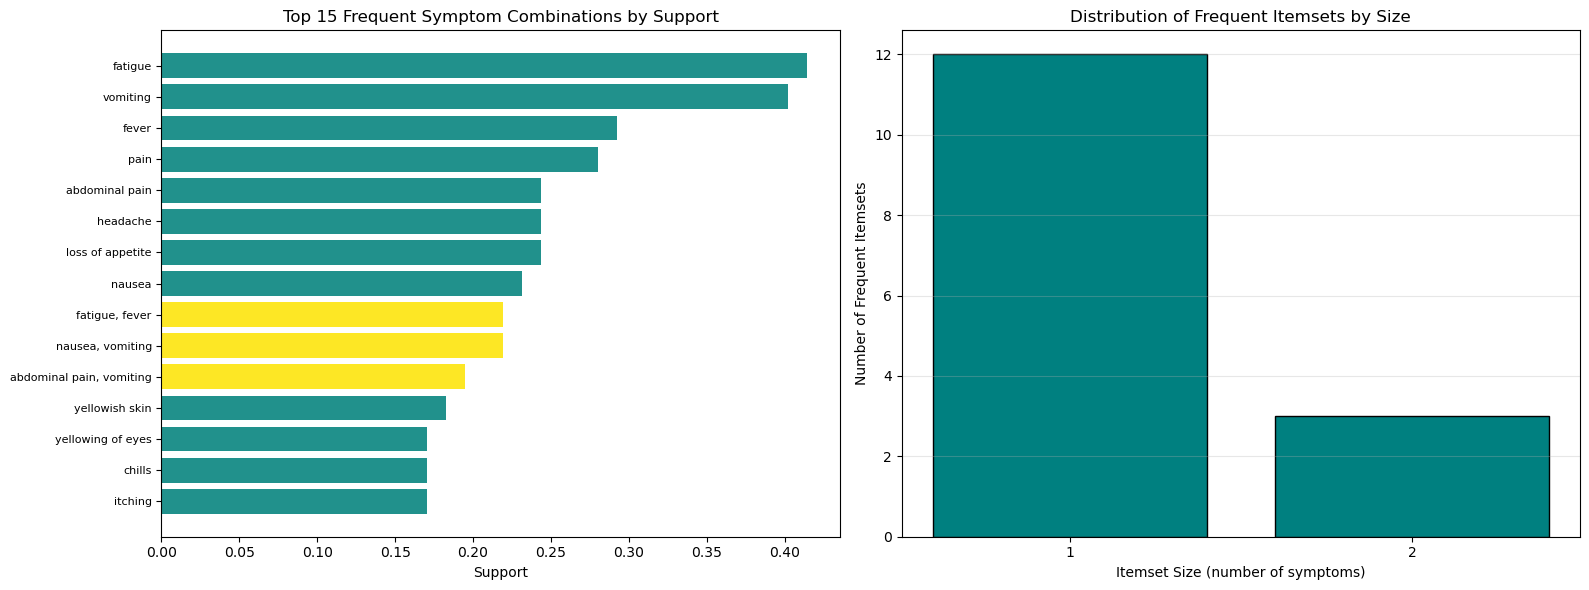

Saved: ./outputs/frequent_itemsets.png

 STEP 7: Generating Association Rules...

Generated 119 association rules
Minimum confidence threshold: 0.5

 STEP 8: Visualizing Association Rules...


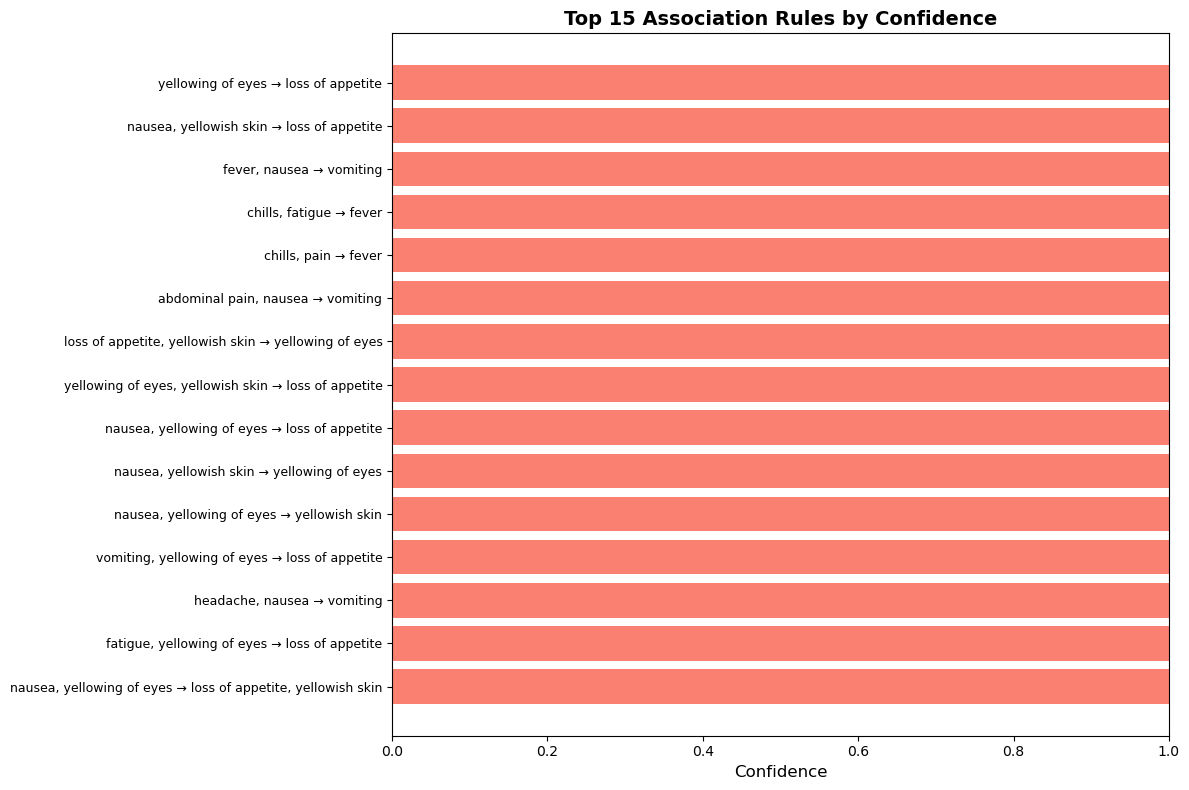

Saved: ./outputs/rules_by_confidence.png


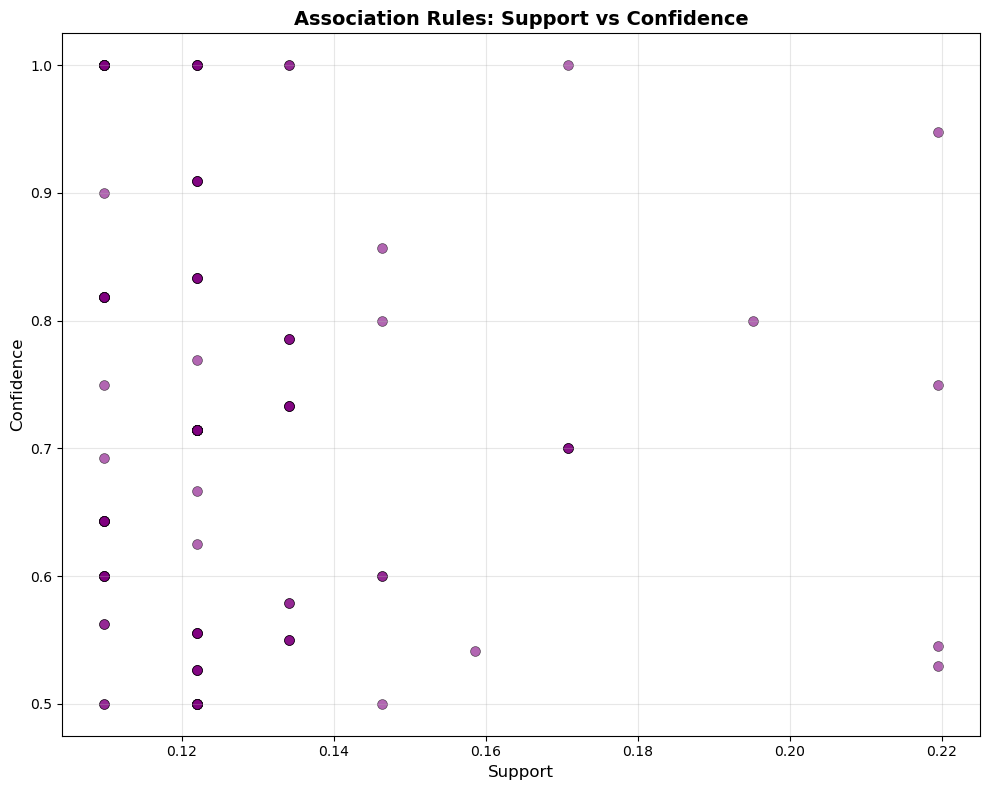

Saved: ./outputs/support_vs_confidence.png


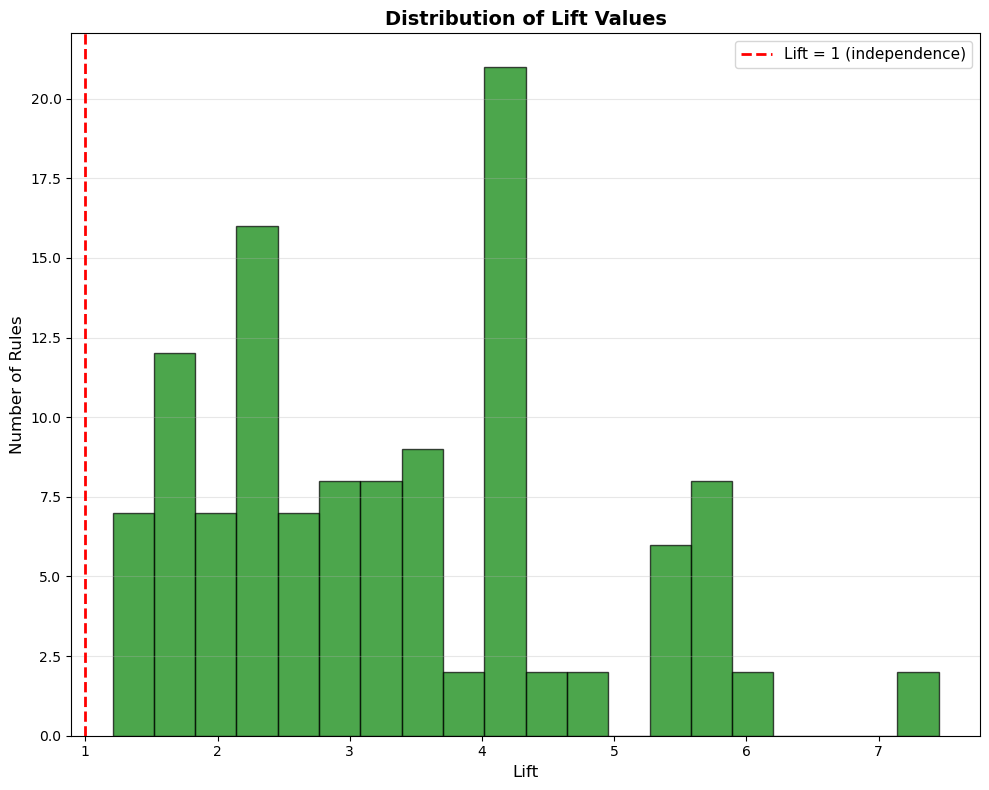

Saved: ./outputs/lift_distribution.png


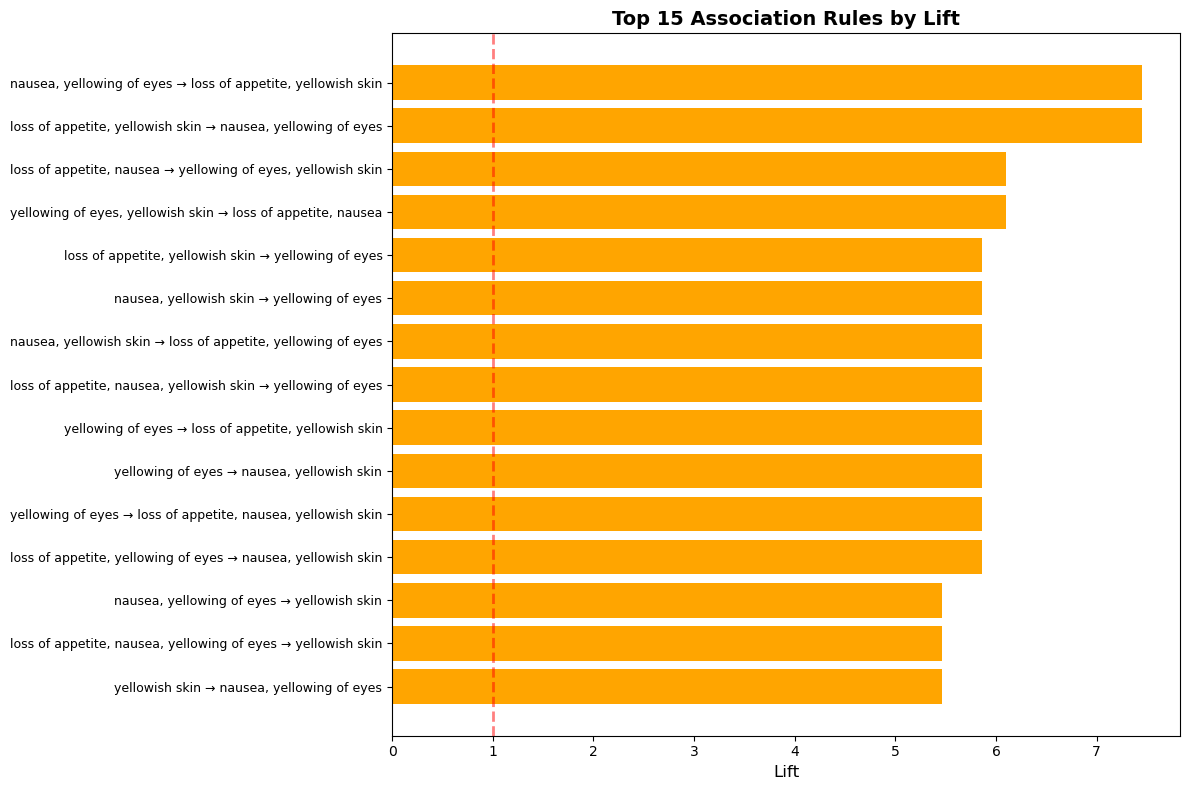

Saved: ./outputs/rules_by_lift.png

 All 4 plots saved successfully!

 STEP 9: Saving Results...

SUMMARY STATISTICS

 Frequent Itemsets:
  Total frequent itemsets: 72
  Size 1: 20 itemsets
  Size 2: 35 itemsets
  Size 3: 16 itemsets
  Size 4: 1 itemsets

 Association Rules:
  Total rules generated: 119
  Average confidence: 0.7231
  Average support: 0.1262
  Average lift: 3.3552

 Top 5 Rules by Confidence:
  1. yellowing of eyes → loss of appetite | Supp: 0.1707, Conf: 1.0000, Lift: 4.1000
  2. nausea, yellowish skin → loss of appetite | Supp: 0.1098, Conf: 1.0000, Lift: 4.1000
  3. nausea, fever → vomiting | Supp: 0.1098, Conf: 1.0000, Lift: 2.4848
  4. fatigue, chills → fever | Supp: 0.1220, Conf: 1.0000, Lift: 3.4167
  5. pain, chills → fever | Supp: 0.1220, Conf: 1.0000, Lift: 3.4167

Saved: ./outputs/frequent_itemsets.csv
Saved: ./outputs/association_rules.csv

TASK 2.1 COMPLETED SUCCESSFULLY!

Generated files in './outputs/' directory:
  1. symptom_distribution.png      - Top s

In [178]:
def main():
    print("="*70)
    print("TASK 2.1: ANALYSIS OF SYMPTOM CO-OCCURRENCE PATTERNS")
    print("Using Apriori Algorithm")
    print("="*70)
    # STEP 1: LOAD DATA
    print("\n STEP 1: Loading Dataset...")
    
    
    filepath = '/Users/sanjana/Desktop/sc4020-project-2/data/disease_symptom/dataset.csv'
    
    df = load_disease_symptom_data(filepath)
    
    if df is None:
        print("\n Cannot proceed without dataset!")
        return
    
    print(f"\nDataset preview:")
    print(df.head())
    
    # STEP 2: PREPARE TRANSACTIONS
    print("\n STEP 2: Preparing Transactions...")
    transactions, disease_names, symptom_stats = prepare_transactions(
        df, 
        normalize_synonyms=True, 
        verbose=True
    )
    
    
    # STEP 3: DATA AUGMENTATION
    print("\n STEP 3: Augmenting Dataset...")
    transactions_aug, names_aug = augment_transactions(
        transactions, 
        disease_names, 
        noise_rate=0.05,
        verbose=True
    )
    
    # STEP 4: VISUALIZE SYMPTOM DISTRIBUTION
    print("\n STEP 4: Visualizing Symptom Distribution...")
    visualize_symptom_distribution(symptom_stats, top_n=20)
    
    # STEP 5: RUN APRIORI ALGORITHM
    print("\n STEP 5: Running Apriori Algorithm...")
    
    # Parameters (adjusted for augmented data)
    MIN_SUPPORT = 0.10      
    MIN_CONFIDENCE = 0.5    
    
    min_count = int(np.ceil(len(transactions_aug) * MIN_SUPPORT))
    
    print(f"\nParameters:")
    print(f"  Total transactions: {len(transactions_aug)}")
    print(f"  Minimum support: {MIN_SUPPORT} ({MIN_SUPPORT*100:.0f}%)")
    print(f"  Minimum absolute count: {min_count} transactions")
    print(f"  Minimum confidence: {MIN_CONFIDENCE} ({MIN_CONFIDENCE*100:.0f}%)")
    print()
    
    # Initialize and run Apriori
    apriori = AprioriAlgorithm(
        min_support=MIN_SUPPORT, 
        min_confidence=MIN_CONFIDENCE
    )
    
    frequent_itemsets = apriori.fit(transactions_aug, verbose=True)
    
    
    # STEP 6: VISUALIZE FREQUENT ITEMSETS
    print("\n STEP 6: Visualizing Frequent Itemsets...")
    visualize_frequent_itemsets(frequent_itemsets, top_n=15)
    
    # STEP 7: GENERATE ASSOCIATION RULES
    print("\n STEP 7: Generating Association Rules...")
    rules = apriori.generate_association_rules(
        min_confidence=MIN_CONFIDENCE, 
        verbose=True
    )
    
    # STEP 8: VISUALIZE ASSOCIATION RULES
    if rules:
        print("\n STEP 8: Visualizing Association Rules...")
        visualize_association_rules(rules, top_n=15)
    else:
        print("\n No association rules found with current thresholds.")
        print("   Try lowering min_confidence or min_support.")
    
    # STEP 9: SAVE RESULTS
    print("\n STEP 9: Saving Results...")
    print_summary_statistics(frequent_itemsets, rules)
    save_results_to_csv(frequent_itemsets, rules)
    
    # ========================================================================
    # COMPLETION
    # ========================================================================
    print("\n" + "="*70)
    print("TASK 2.1 COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"\nGenerated files in '{OUTPUT_DIR}/' directory:")
    print("  1. symptom_distribution.png      - Top symptoms visualization")
    print("  2. frequent_itemsets.png          - Frequent patterns chart")
    print("  3. association_rules.png          - Rules visualization")
    print("  4. frequent_itemsets.csv          - Frequent itemsets data")
    print("  5. association_rules.csv          - Association rules data")
    print("\n" + "="*70)


if __name__ == "__main__":
    # Run main analysis
    main()